<a href="https://colab.research.google.com/github/solomeya12345-code/python_for_data_analitic/blob/main/Homework_4_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому домашньому завданні ми продовжуємо працювати з набором даних `Yulu`, з яким почали працювати в "hw 4.3. Робота з DataFrame. Діаграма розсіювання.". Фокус цього ДЗ в тому, аби будувати візуалізації використовуючи методи бібліотеки `seaborn`. Це дозволяє будувати гарніні візуалізації, а іноді також робити це швидше, ніж з `matplotlib`.

Документація до тої частини бібліотеки, з якою тут працюємо

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

### Профіль колонок набору даних:

- **datetime**: дата та час зібрані погодинно
- **season**: сезон (1: весна, 2: літо, 3: осінь, 4: зима)
- **holiday**: чи є день святковим (витягнуто з http://dchr.dc.gov/page/holiday-schedule)
- **workingday**: якщо день не є вихідним або святковим, то позначається як 1, в іншому випадку – 0.
- **weather**:
  1. Ясно, Мало хмарно, частково хмарно
  2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
  3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
  4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман
- **temp**: температура в градусах Цельсія
- **atemp**: як відчувається температура в градусах Цельсія
- **humidity**: вологість
- **windspeed**: швидкість вітру
- **casual**: кількість неформальних користувачів
- **registered**: кількість зареєстрованих користувачів
- **count**: загальна кількість велосипедів, взятих в оренду, включаючи неформальних та зареєстрованих користувачів

0. Імпортуйте бібліотеки `matplotlib.pyplot`, `seaborn` та `pandas`.  Завантажте дані з файла `yulu_rental.csv` у `pandas.DataFrame` `df`.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('drive/MyDrive/Python_for_DA/yulu_rental.csv')

1. Користуючись методом `seaborn.jointplot` побудуйте візуалізацію графіка розсіювання між змінними `humidity` та `count`, зазначивши колір точки в відповідності до значення змінної `weather`. Опишіть свої спостереження з графіку. Що бачите цікавого і корисного для прийняття рішень на основі цих даних?

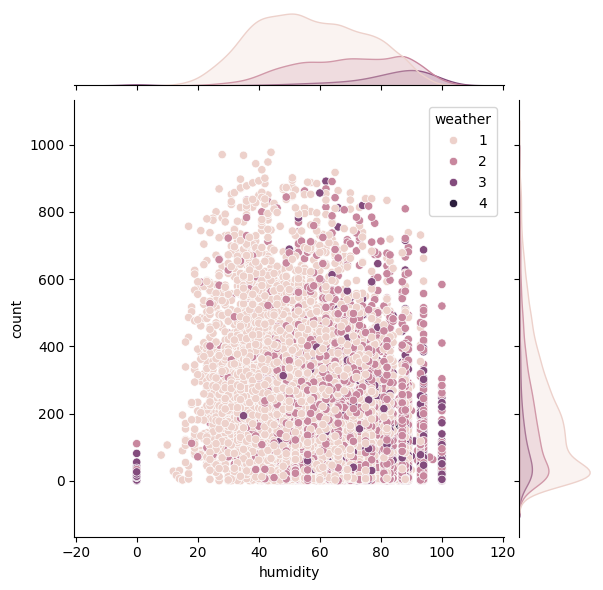

In [5]:
sns.jointplot(data=df, x="humidity", y="count", hue="weather");

Відносно вологості бачимо, що точки розпреділені рівномірно по графіку. А це означає, що на кількість користувачів вологість не дуже впливала.

Відносно осі з кількістю користувачів, бачимо, що не дуже залежно від вологості, кількість зосереджена в більшості між 0 та 200. Чим більша кількість користувачів на осі, тим менше ми бачимо точок.

З точки зору погоди бачимо, що ясна погода в більшості зосереджена між 20 та 60 показниками вологості. Також погода з сильним дощем, грозою, туманом і т.д. більше зустрічається при високій вологості повітря. І бачимо, що туманна погода зосереджена більше між 40 та 100 показниками вологості, що теж логічно.

Але все ж таки, найбільша кількість користувачів зустрічається в межах 20 та 40 показниками вологості. Це може бути корисно для розуміння, коли більше користуються послугами та провадженнями акцій, можливо, або спеціальних пропозицій в інші погодні умови.

**Відповідь**
Можливі спостереження

1. **Щільність точок**: здається, існує великий розкид точок за різними рівнями вологості з щільним групуванням на нижчих рівнях вологості. Це вказує на те, що кількість велосипедів на прокат при нижчому рівні вологості зростає.

2. **Категорії погоди**: погодні умови, позначені кольором, показують переважання різних типів погоди в пунктах оренди. Ми можемо помітити, що в ясні та похмурі дні (1 і 2) більше орендованих велосипедів у порівнянні до днів з опадами (3 і 4).

3. **Викиди**: помітні викиди, такі як оренда великої кількості велосипедів навіть у дні з поганою погодою (3 і 4) або дуже високим рівнем вологості. Цікаво дослідити ці викиди окремо.

4. **Граничні розподіли**: на верхньому та правому полях  графіка бачимо розподіли даних за категоріями.Бачимо, що найбільше точок є з ясною погодою і вологість в ці дні - нижча, ніж в дні з погодою похмурою та з опадами.


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=16BksRhZzoz4ynPKCPjXEek56XBsAEF6T)

2. Відфільтруйте і збережіть в окремій змінній лише дані з сезоном "весна" і "літо" (звернітся до опису даних вгорі ноутбуку, аби зрозуміти, які значення вам треба обрати.
Користуючись методом `seaborn.jointplot` побудуйте візуалізацію графіка розсіювання між змінними `casual` та `registered`, зазначивши колір точки в відповідності до значення змінної `season`. Встановіть прозорість на 0.2.

Опишіть свої спостереження з графіку. Що бачите цікавого і корисного для прийняття рішень на основі цих даних?

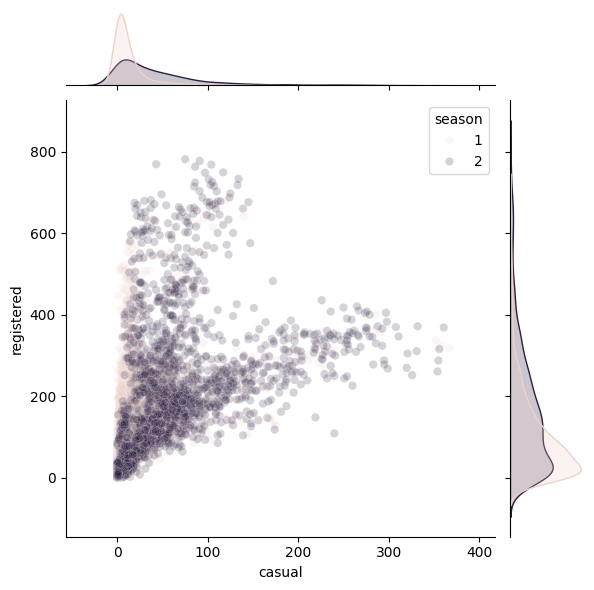

In [6]:
spring_summer = df[df['season'].isin([1, 2])]
sns.jointplot(data=spring_summer, x="casual", y="registered", hue="season", alpha=.2);

Бачимо, що кількість неформальних користувачів весною є у проміжку від 0 до 100 здебільшого. Улітку вже з'являється більше неформальних користувачів.

Зареєстрованих весною також менше, а в літку стає вже трохи більше.

Графік нас підводить до думки, що зареєстрованих користувачів загалом їздить більше і влітку, і весною, що може спонукати залучати нових зареєстрованих користувачів. А також влітку збільшується загалом кількість усіх користувачів.

Відповідь:

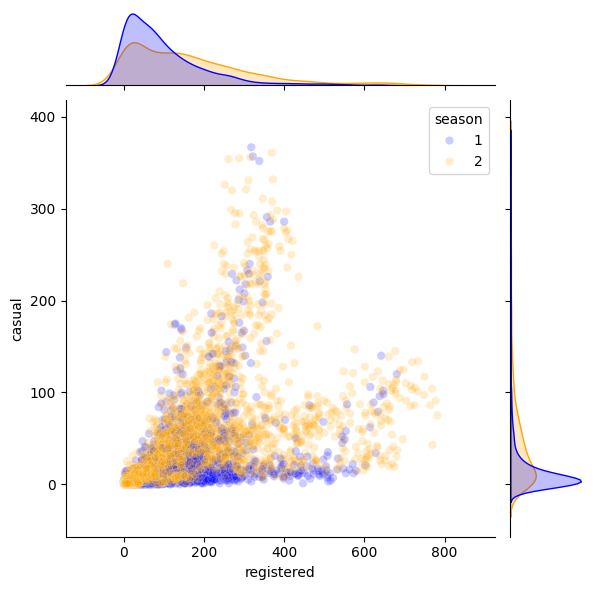

In [40]:
df_filtered = df[df.season.isin([1,2])].copy(deep=True)

# тут для легшого проведення спостережен я встановила спеціальні кольори через параметр palette
sns.jointplot(data=df_filtered,
              x="registered",
              y="casual",
              hue='season',
              alpha=0.2, palette=["blue", "orange"]);

**Відповідь**

Спостереження з графіку:

1. **Залежність між зареєстрованими та неформальними користувачами**: Здається, що існує позитивна кореляція між кількістю зареєстрованих та неформальних користувачів — коли одна категорія користувачів збільшується, збільшується і інша. Проте, кількість зареєстрованих користувачів зазвичай вища ніж кількість неформальних. До того ж, чомусь є "розгалуження" у дві лінії на графіку розсіювання. Схоже, що існує фактор, який стимулює брати велосипеди в аренду, але не стимулює реєструватись.

2. **Вплив сезонності на неформальних користувачів**: Здається, що неформальні користувачі більш активні в літні місяці. Можна припустити, що хороші погодні умови і канікули сприяють цій тенденції.

3. **Розподіл активності**: Маржинальні гістограми на верхньому та правому краю графіка показують розподіл кількості неформальних та зареєстрованих користувачів відповідно. Ці розподіли підтверджують, що у літній сезон спостерігається вищий рівень користування велопрокатом, особливо серед неформальних користувачів.

3. Для дослідження як розподілу значень  `humidity` в залежності від погоди (`weather`) побудуйте візуалізацію типу "ящик з вусами" (box plot)користуючись відповідним методом бібліотеки seaborn:

https://seaborn.pydata.org/generated/seaborn.boxplot.html


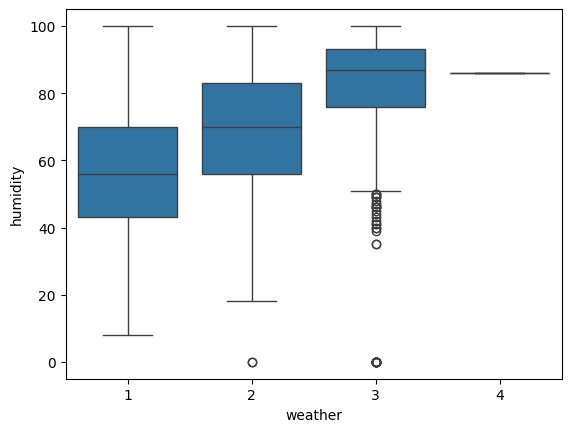

In [7]:
sns.boxplot(data=df, x='weather', y='humidity');

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1_6CBacvDlbuV1XD9GNoGn9sJOSfr74pS)


4. Використайте бібліотеку Seaborn для створення **парних графіків** (pairplot) розсіювання, які показуватимуть взаємозв'язки між кількістю зареєстрованих, неформальних користувачів та загальною кількістю велосипедів, взятих на прокат. Кожен графік повинен розрізняти робочі та святкові дні за кольором.

Для побудови цієї візуалізації спочатку відфільтруйте потрібні колонки в даних і потім зробіть візуалізацію.

Проаналізуйте візуалізацію і скажіть, чи можна виявити особливу поведінку користувачів у святкові дні з цих графіків?

In [4]:
df['day_type'] = df.apply(
    lambda row: 'holiday' if row['holiday'] == 1
                else ('working' if row['workingday'] == 1
                      else 'weekend'),
    axis=1
)

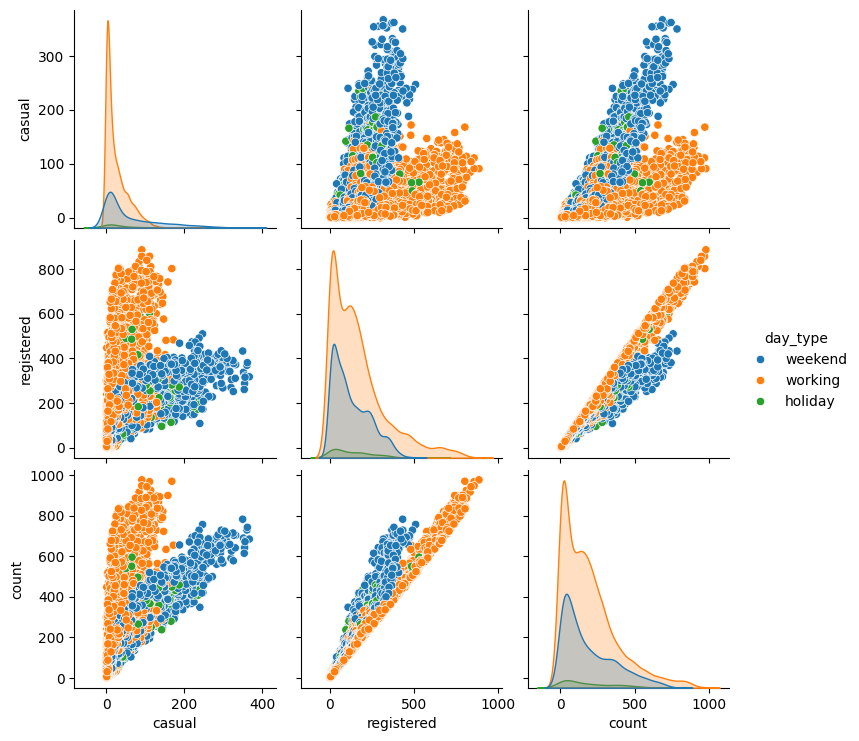

In [13]:
all_users_daytype = df[['casual', 'registered', 'count', 'day_type']]
sns.pairplot(data=all_users_daytype, hue="day_type");

Моя альтернатива:

In [12]:
all_users = df[['casual', 'registered', 'count', 'holiday']]
all_users[:3]

,casual,registered,count,holiday
0,3,13,16,0
1,8,32,40,0
2,5,27,32,0


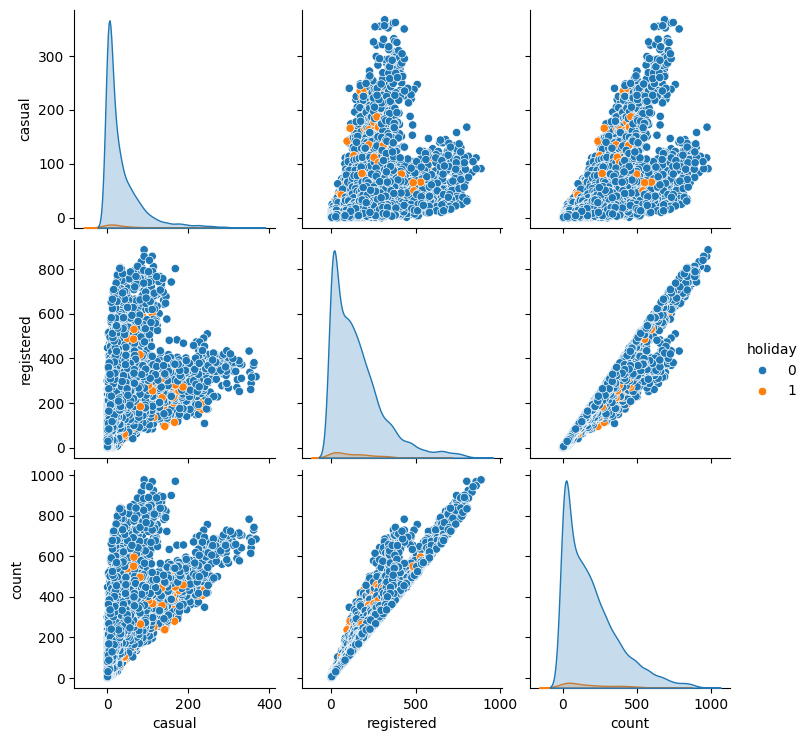

In [14]:
sns.pairplot(data=all_users, hue="holiday");

Моя відповідь:

По графіку можемо побачити, що є тенденція така, що у святкові дні користувачі їздять більше. Незареєстровані користувачі частіше користуються велосипедами у святкові дні.

**Відповідь на питання**

З графіків не можемо зробити висновок про особливість поведінки користувачів у світкові дні. Можливо, треба більше даних в ці дні аби почали вимальовуватись закономірності.

5. Змініть тип даних колонки `datetime` на `pandas.datetime`.

In [18]:
df[:2]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_type
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,weekend
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,weekend


In [20]:
df['datetime'] = pd.to_datetime(df.datetime)

 Тепер давайте візуалізуємо кількість зареєстрованих та казуальних користувачів поденно. Для цього виконайте код нижче і після цього створіть нову змінну `df_viz` яка містить лише колонки `'date', 'registered', 'casual'`, згрупуйте дані за датою і відобразіть на **одному** графіку поденну динаміку двох показників з допомогою `pandas.plot`.

In [21]:
df['date'] = df.datetime.dt.date

In [28]:
df_viz = df[['date', 'registered', 'casual']].groupby('date').sum()
df_viz[:5]

,registered,casual
date,,
2011-01-01,654,331
2011-01-02,670,131
2011-01-03,1229,120
2011-01-04,1454,108
2011-01-05,1518,82


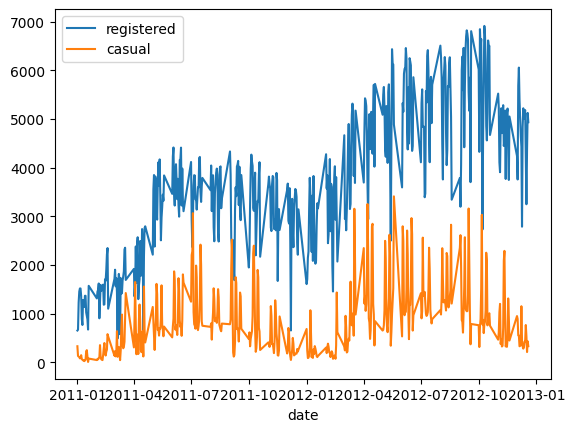

In [36]:
plt.plot(df_viz.index, 'registered', data=df_viz, label='registered')
plt.plot(df_viz.index, 'casual', data=df_viz, label='casual')

plt.xlabel('date')
plt.legend();

Або:

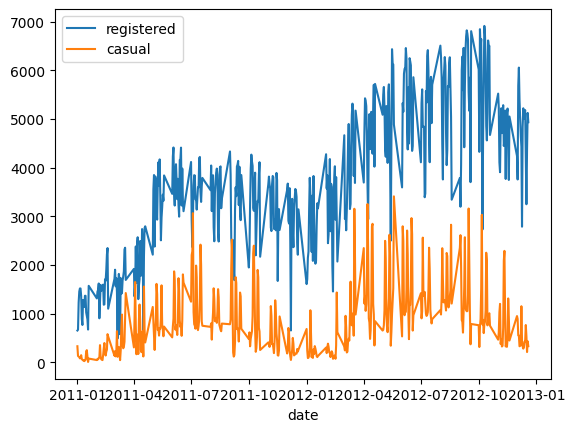

In [42]:
# найпростіше
df_viz.plot();

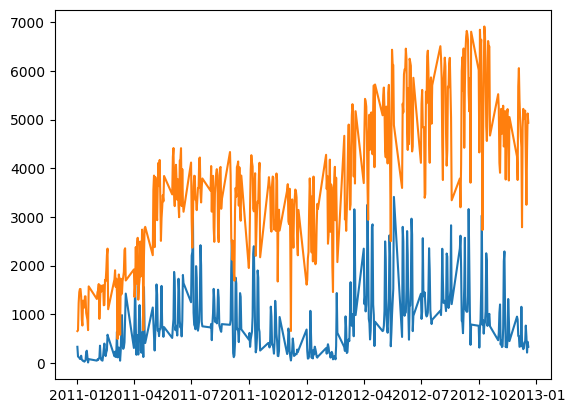

In [41]:
# ще один варіант
plt.plot('date', 'casual', data=df_viz.reset_index())
plt.plot('date', 'registered', data=df_viz.reset_index());

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1XGBqmFLXiI_v-MBEOiCQNyW6sUpvII1n)
